In [1]:
import cv2
import os
import re
import torch
import torchvision
import numpy as np
import pandas as pd
import random
import xml.etree.ElementTree as ET
import torchvision.transforms as T
from PIL import Image
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torch.utils.data import DataLoader, Dataset
from matplotlib import pyplot as plt
from matplotlib import patches
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device="cpu"
print(device)

cuda


In [3]:
# from torchvision.datasets import VOCDetection
# #downLoad Pascal VOC dataset
# VOCDetection(root='VOC_data', year='2012', image_set='trainval', download=True)

In [4]:
# Define VOC_CLASSES # 0 is for background
VOC_CLASSES = {
    "bicycle": 2, "bus": 6, "car": 7, "motorbike": 14, "person": 15
}
# Re-index values
VOC_CLASSES = {name: idx+1 for idx, (name, _) in enumerate(VOC_CLASSES.items())}
print(VOC_CLASSES)

{'bicycle': 1, 'bus': 2, 'car': 3, 'motorbike': 4, 'person': 5}


In [5]:
# get model
def get_model(num_classes):
    # Load the pre-trained Faster R-CNN model with ResNet50 backbone
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT, progress=True, 
                                weights_backbone=ResNet50_Weights.DEFAULT, trainable_backbone_layers=0)

    # replace for custom classes
    in_features = model.roi_heads.box_predictor.cls_score.in_features  # Get input features of the classifier
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)  # Replace with a new head
    
    #print(model)
    return model

In [6]:
# Number of object classes + 1 background
num_classes = len(VOC_CLASSES) + 1 

# Load the Faster R-CNN model
model = get_model(num_classes)
# to device
model.to(device)
# fine tunning classes
model.roi_heads.box_predictor

FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=6, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=24, bias=True)
)

In [7]:
# transform
model.transform

GeneralizedRCNNTransform(
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    Resize(min_size=(800,), max_size=1333, mode='bilinear')
)

In [8]:
# VOC_CLASSES_inverted
VOC_CLASSES_inverted = {v: k for k, v in VOC_CLASSES.items()}
print(VOC_CLASSES_inverted)

{1: 'bicycle', 2: 'bus', 3: 'car', 4: 'motorbike', 5: 'person'}


In [9]:
# Initialize optimizer and learning rate scheduler
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', 
                                                      factor=0.1, patience=3
                                                      )

In [10]:
def plot_training_history(history):
    """Plot training and validation metrics using dictionary input"""
    plt.figure(figsize=(18, 8))
    
    # Plot training loss
    plt.subplot(2, 2, 1)
    plt.plot(history['train_loss'], label='Training Loss')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot mAP
    plt.subplot(2, 2, 2)
    plt.plot(history['val_map'], label='Validation mAP')
    plt.title('Validation mAP over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('mAP')
    plt.legend()
    plt.grid(True)
    
    # Plot Precision/Recall
    plt.subplot(2, 2, 3)
    plt.plot(history['val_precision'], label='Precision')
    plt.plot(history['val_recall'], label='Recall')
    plt.title('Precision and Recall over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    
    # Plot IoU
    plt.subplot(2, 2, 4)
    plt.plot(history['val_iou'], label='Validation IoU')
    plt.title('Validation IoU over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()
    plt.close()

In [11]:
# Function to load the best model
def load_best_model(model, optimizer, load_path):
    if os.path.exists(load_path):
        checkpoint = torch.load(load_path, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        best_map = checkpoint['best_map']
        epoch = checkpoint['epoch']
        history = checkpoint['history']
        print(f"Loaded best model with mAP: {best_map:.4f} from epoch {checkpoint['epoch']+1}")
        return model, optimizer, best_map, epoch, history
    else:
        print("No saved model found.")
        return model, optimizer, 0.0, -1

### Inference

In [12]:
# load the best model:
        #, history
model, optimizer, best_map, epoch, history  = load_best_model(model, optimizer, load_path='checkpoints_224/best_model.pth')
model = model.to(device)

Loaded best model with mAP: 0.5691 from epoch 12


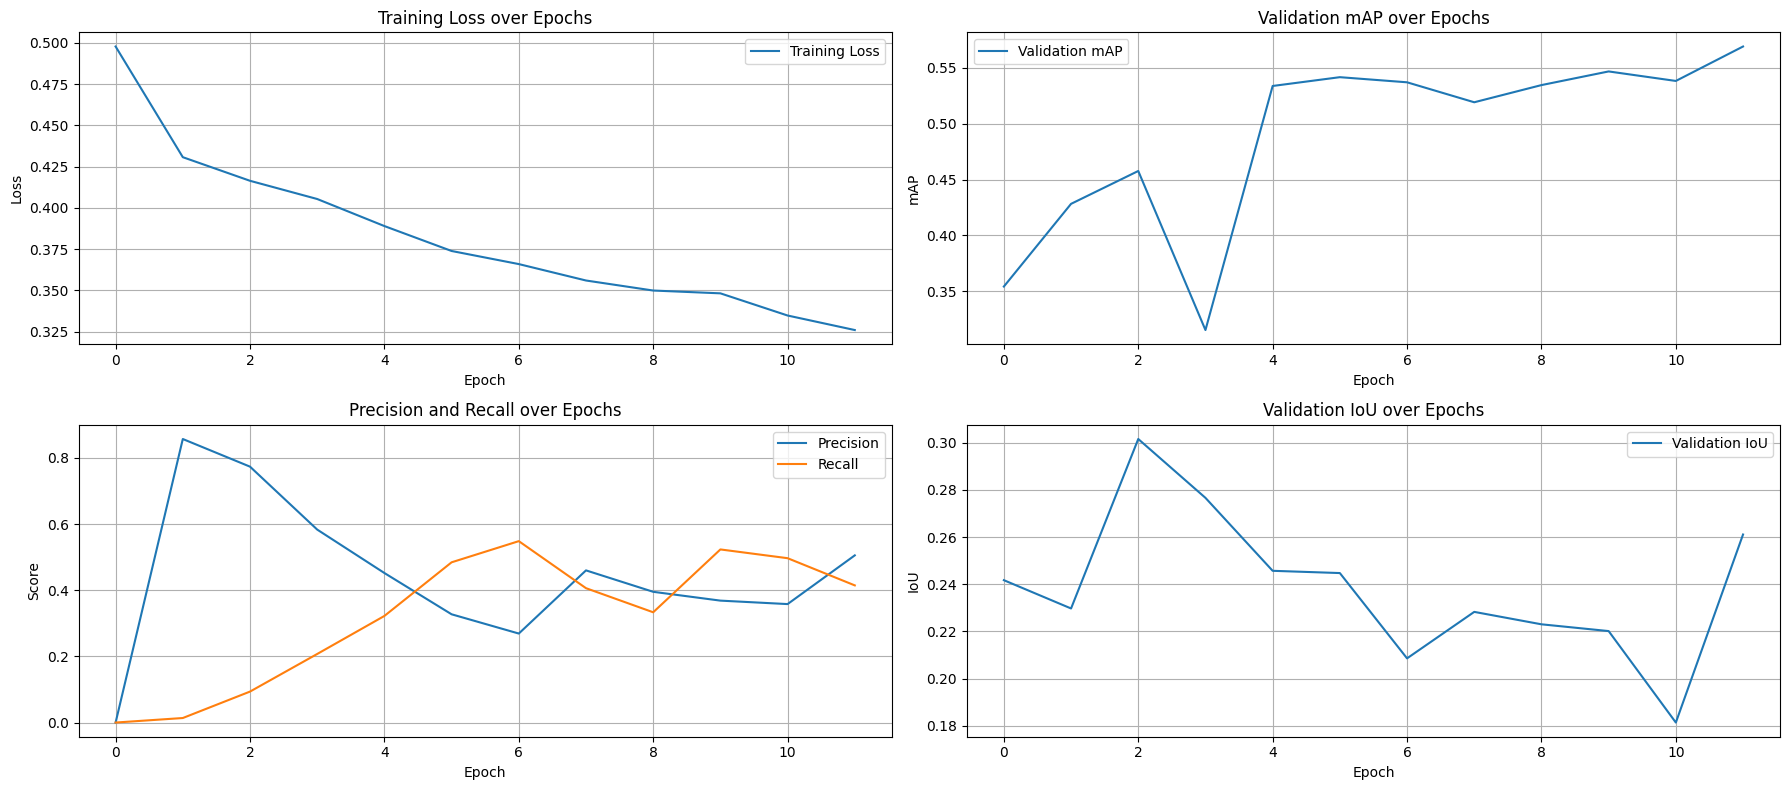

In [13]:
# Load history from checkpoint
plot_training_history(history)

In [14]:
# Get best mAP value
best_map = max(history['val_map'])

# Get epoch with best mAP
best_epoch = history['val_map'].index(best_map)

# Print best results
print(f"Best mAP: {best_map:.4f} at epoch {best_epoch + 1}")
print(f"Corresponding Precision: {history['val_precision'][best_epoch]:.4f}")
print(f"Corresponding Recall: {history['val_recall'][best_epoch]:.4f}")

Best mAP: 0.5691 at epoch 12
Corresponding Precision: 0.5054
Corresponding Recall: 0.4146


In [15]:
def predict_image(model, image, device, confidence_threshold=0.5):
    
    model.eval()
   
    transform = T.Compose([
        #T.Resize((400, 600)),
        T.ToTensor(),  
        T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
        ])
    image = transform(image)
    
    # Prepare image for model
    image = image.to(device)
    
    # Get predictions
    with torch.no_grad():
        predictions = model([image])
    
    # Get boxes, labels and scores
    boxes = predictions[0]['boxes'].cpu()
    labels = predictions[0]['labels'].cpu()
    scores = predictions[0]['scores'].cpu()
    
    # Filter by confidence
    mask = scores >= confidence_threshold
    boxes = boxes[mask]
    labels = labels[mask]
    scores = scores[mask]
    
    return boxes, labels, scores

In [16]:
def visualize_predictions(image, boxes, labels, scores, VOC_CLASSES, save_path="predictions_img"):
        
    # Create figure and axes
    fig, ax = plt.subplots(1)
    ax.imshow(image)
    
    # Draw each box
    for box, label, score in zip(boxes, labels, scores):
        #print(label)
        #print(scores)
        # Convert box coordinates to integers
        box = box.numpy().astype(np.int32)
        
        # Create rectangle patch
        rect = patches.Rectangle(
            (box[0], box[1]),
            box[2] - box[0],
            box[3] - box[1],
            linewidth=2,
            edgecolor='r',
            facecolor='none'
        )
        ax.add_patch(rect)
        # Add label and score
        class_name = VOC_CLASSES_inverted.get(label.item(), "Unknown") # classes start in 1, do not substract???
        ax.text(
            box[0],
            box[1] - 5,
            f'{class_name}: {score:.2f}',
            bbox=dict(facecolor='red', alpha=0.5),
            color='white'
        )
    
    # Remove axes
    plt.axis('off')
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
        plt.close()
    else:
        plt.show()


In [17]:
# Single image inference
image_path = 'img.jpg'
image = Image.open(image_path).convert('RGB')

boxes, labels, scores = predict_image(model, image, device)   # image, ???
visualize_predictions(image, boxes, labels, scores, VOC_CLASSES)

# Batch processing
#batch_inference(model, 'test_images', 'results', VOC_CLASSES, device)

# Save results to CSV
#save_results(boxes, labels, scores, class_names, 'results.csv')

In [18]:
def process_video(model, video_path, output_path, class_names, device, 
                 confidence_threshold=0.5, fps=30):
    """
    Process video file and save annotated video
    """
    # Open video file
    cap = cv2.VideoCapture(video_path)
    #cap = cv2.VideoCapture(0)  # Use 0 for default webcam, or provide IP camera URL

    # Check if the camera opened successfully
    if not cap.isOpened():
        print("Error: Could not open video stream.")
        return
        
    # Get video properties
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Create video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))
    #out = cv2.VideoWriter(output_path, fourcc, fps, (600, 400)) #resize video output
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            print("Error: Could not read frame.")
            break

        # risize frame to 600x400
        #frame = cv2.resize(frame, (600, 400))
        # Convert BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Convert to PIL Image
        image = Image.fromarray(frame_rgb)

        # Get predictions
        boxes, labels, scores = predict_image(model, image, device, confidence_threshold)
        
        # Draw predictions on frame
        for box, label, score in zip(boxes, labels, scores):
            box = box.numpy().astype(np.int32)
            class_name = VOC_CLASSES_inverted.get(label.item(), "Unknown")
            
            # Draw box
            cv2.rectangle(frame, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
            
            # Add label
            label_text = f'{class_name}: {score:.2f}'
            cv2.putText(frame, label_text, (box[0], box[1] - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        # Display the processed frame
        cv2.imshow('Video', frame)
        
        # Write frame
        out.write(frame)

        # Exit on 'q' key press
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Release everything
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    

In [19]:
# Video processing
#process_video(model, 'input.mp4', 'output.mp4', VOC_CLASSES, device)

In [25]:
# Video processing
process_video(model, 0, 'output_web.mp4', VOC_CLASSES, device)

[ WARN:0@1270.019] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


In [21]:
def batch_inference(model, image_folder, output_folder, class_names, device, 
                   confidence_threshold=0.5):
    """
    Process all images in a folder
    """
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all image files
    image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(
        ('.png', '.jpg', '.jpeg', '.tiff', '.bmp'))]
    
    for image_file in tqdm(image_files, desc="Processing images"):
        # Load image
        image_path = os.path.join(image_folder, image_file)
        image = Image.open(image_path).convert('RGB')
        
        # Get predictions
        boxes, labels, scores = predict_image(model, image, device, confidence_threshold)
        
        # Visualize and save
        output_path = os.path.join(output_folder, f'pred_{image_file}')
        visualize_predictions(image, boxes, labels, scores, class_names, output_path)


In [24]:
"""

# Additional utility functions
def get_color_map(num_classes):
    """Generate different colors for different classes"""
    colors = plt.cm.rainbow(np.linspace(0, 1, num_classes))
    return colors

def create_results_table(boxes, labels, scores, class_names):
    """Create a pandas DataFrame with detection results"""
    results = []
    for box, label, score in zip(boxes, labels, scores):
        results.append({
            'class': class_names[label - 1],
            'confidence': f"{score:.3f}",
            'bbox': f"[{box[0]:.1f}, {box[1]:.1f}, {box[2]:.1f}, {box[3]:.1f}]"
        })
    return pd.DataFrame(results)

def save_results(boxes, labels, scores, class_names, output_path):
    """Save detection results to CSV"""
    df = create_results_table(boxes, labels, scores, class_names)
    df.to_csv(output_path, index=False)

"""

SyntaxError: invalid syntax (3405285051.py, line 5)